User Topic --> Create explanantion --> Create real world examples

In [33]:
import os 
from dotenv import load_dotenv
from typing import TypedDict


from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END

1. Load API keys


In [34]:
load_dotenv()

True

2. Create LLM

In [35]:

model = init_chat_model(
    "openai/gpt-oss-20b",
    model_provider="openrouter",
    temperature=0
)


3. Create state

In [36]:
class State(TypedDict):
    topic: str
    explanation:str
    real_world_examples: str

4. Create Explanation Node

In [37]:
def generate_explanation(state):

    prompt = f"Explain the topic '{state['topic']}' in 150 words in what, why, how, limitations, how to overcome them format."

    response = model.invoke(prompt)

    return {"explanation": response.content}

5. Create real world example node

In [38]:
def generate_example(state):

    prompt = f"Provide 2 real-world examples for the concept '{state['topic']}'."

    response = model.invoke(prompt)

    return {"real_world_examples": response.content}

5. Create Graph

In [39]:
builder = StateGraph(State)

6. Add Node

In [40]:
builder.add_node("generate_explanation", generate_explanation)
builder.add_node("generate_example", generate_example)

7. Add edges

In [41]:
builder.add_edge(START, "generate_explanation")
builder.add_edge(START, "generate_example")
builder.add_edge("generate_explanation", END)
builder.add_edge("generate_example", END)

8. Compile

In [42]:
graph = builder.compile()

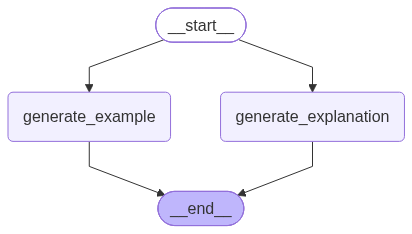

In [43]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

9. Invoke

In [44]:
result = graph.invoke({"topic": "Langgraph"})

10. Print Response

In [45]:
print(result["topic"])

Langgraph


In [46]:
print(result["explanation"])


**What:**  
Langgraph is a Python framework that lets developers design, execute, and debug complex language‑model pipelines as directed graphs. It abstracts LLM calls, memory, and state transitions into nodes and edges, enabling modular, reusable workflows.  

**Why:**  
Traditional monolithic LLM scripts are hard to maintain, test, and scale. Langgraph provides a visual, declarative way to compose tasks, track provenance, and enforce constraints, making it easier to build reliable AI applications.  

**How:**  
Users define nodes (functions or LLM prompts) and connect them with edges in a graph. The runtime handles token streaming, state persistence, and error handling, while offering tools for logging, visualization, and unit testing.  

**Limitations:**  
It can introduce overhead for simple use cases, and debugging deep graphs may still be challenging. Integration with non‑Python services requires adapters.  

**How to Overcome:**  
Keep graphs small for trivial tasks, use the pro

In [47]:
print(result["real_world_examples"])

**1. Customer‑Support Chatbot for an E‑Commerce Platform**

| What it does | How Langgraph powers it |
|--------------|------------------------|
| Handles a customer’s entire support journey – from product inquiries, order status checks, to returns and refunds. | • **State graph**: Each node represents a “support stage” (e.g., “greeting”, “order‑lookup”, “refund‑process”, “escalation”). <br>• **LLM prompts**: At every node the LLM generates the next utterance or action based on the current state and the user’s last message. <br>• **Edge conditions**: Transitions are driven by simple rules (e.g., “if order ID is valid → go to order‑lookup node”). <br>• **External API calls**: The graph can invoke the order‑management API to fetch real‑time data, then feed that back into the LLM for a natural response. <br>• **Memory & rollback**: If the user says “I want to cancel”, the graph can roll back to a “cancellation‑confirmation” node, ensuring the conversation stays coherent. |

**Result**: A 

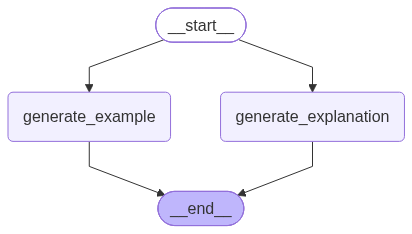

In [48]:
graph

In [49]:
print (type(graph))

<class 'langgraph.graph.state.CompiledStateGraph'>
